In [1]:
import pandas as pd
import numpy as np
import json
import ast
import glob
import warnings
import os
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import figure
%matplotlib inline
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

#Matplotlib Settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color Palette
COLORS = {
    'primary': '#E50914',      # Netflix Red
    'secondary': '#FFD700',    # Gold
    'dark': '#1A1A2E',         # Navy Blue
    'accent': '#16213E',       # Accent
    'light': '#F5F5F5',
    'gradient': ['#E50914', '#FF6B35', '#FFD700', '#00D4AA', '#0077B6'],
}

OUTPUT_DIR = os.path.join(os.getcwd(), 'charts')
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
#SECTION 1: DATA LOADING & PREPARATION
df = pd.read_csv("tmdb_5000_movies.csv")
print(f"Raw Data: {df.shape[0]} Films, {df.shape[1]} Features")

Raw Data: 4803 Films, 20 Features


In [3]:
#Parse JSON columns
def parse_json_col(text):
    try:
        return json.loads(text.replace("'", '"')) #In Python, JSON is sometimes written with single quotes ('), but the JSON standard requires double quotes (").
    except:
        try:
            return ast.literal_eval(text)
        except:
            return []

def extract_names(json_str): #functions that parse name values.
    items = parse_json_col(json_str) if isinstance(json_str, str) else []
    return [item['name'] for item in items if 'name' in item]

In [4]:
df['genre_list'] = df['genres'].apply(extract_names)
df['keyword_list'] = df['keywords'].apply(extract_names)
df['company_list'] = df['production_companies'].apply(extract_names)
df['country_list'] = df['production_countries'].apply(extract_names)

In [5]:
df["release_date"] = pd.to_datetime(df['release_date'], errors='coerce')
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month

In [6]:
budget_0_1000 = df["budget"].between(0, 1000).sum()
print(f"{budget_0_1000} films have a budget between 0 and 1000")

revenue_0_1000 = df["revenue"].between(0, 1000).sum()
print(f"{revenue_0_1000} films have a revenue between 0 and 1000")

df_clean = df[(df["budget"] > 1000) & (df["revenue"] > 1000)] 
print(f"Clean dataset: {df_clean.shape[0]} films (budget and revenue > $1k)")

1069 films have a budget between 0 and 1000
1449 films have a revenue between 0 and 1000
Clean dataset: 3211 films (budget and revenue > $1k)


In [7]:
df_clean["roi"] = ((df_clean["revenue"] - df_clean["budget"]) / df_clean["budget"]) * 100
df_clean["profit"] = df["revenue"] - df_clean["budget"]
df_clean["is_hit"] = (df_clean["roi"] > 100).astype(int) #2x+ revenue = hit
df_clean['log_budget'] = np.log1p(df_clean['budget'])
df_clean['log_revenue'] = np.log1p(df_clean['revenue'])

print(f"ROI Mean: %{df_clean['roi'].median():.0f}")
print(f"Hit ratio (2x+ revenue): %{df_clean['is_hit'].mean()*100:.1f}")

ROI Mean: %130
Hit ratio (2x+ revenue): %56.0


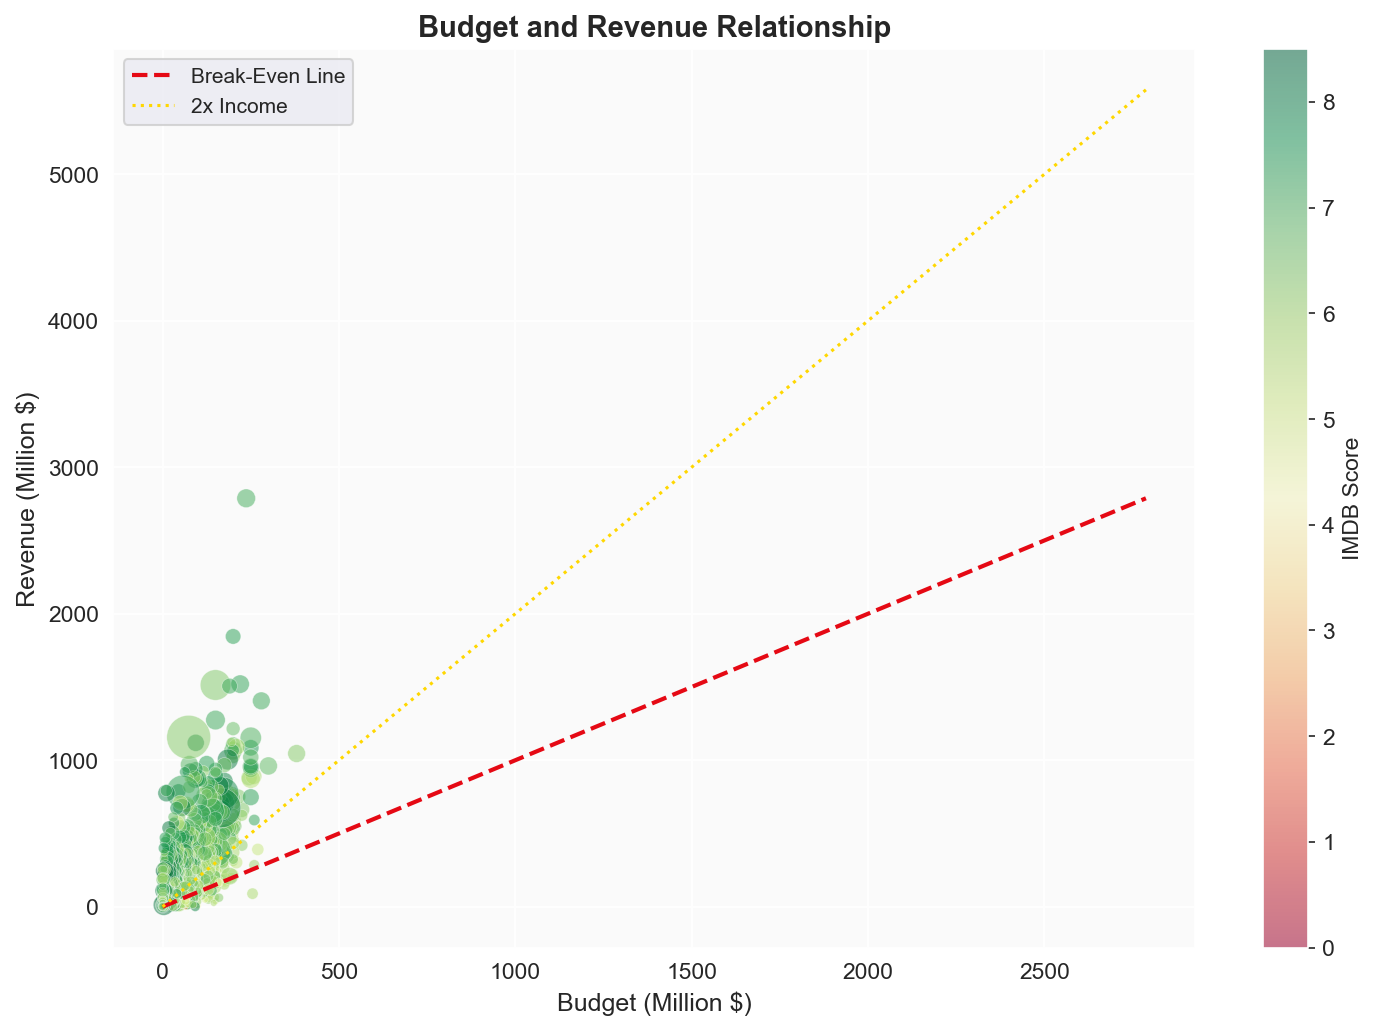

In [8]:
#CHAPTER 2: EXPLORATORY DATA ANALYSIS (EDA)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df_clean['budget'] / 1e6,
    df_clean['revenue'] / 1e6,
    c=df_clean['vote_average'],
    cmap='RdYlGn',
    alpha=0.5,
    s=df_clean['popularity'] / 2 + 5,
    edgecolors='white',
    linewidth=0.3
)
# Break-even çizgisi
max_val = max(df_clean['budget'].max(), df_clean['revenue'].max()) / 1e6
ax.plot([0, max_val], [0, max_val], '--', color=COLORS['primary'], linewidth=2, label='Break-Even Line')
ax.plot([0, max_val], [0, max_val * 2], ':', color=COLORS['secondary'], linewidth=1.5, label='2x Income')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('IMDB Score', fontsize=11)
ax.set_xlabel('Budget (Million $)', fontsize=12)
ax.set_ylabel('Revenue (Million $)', fontsize=12)
ax.set_title('Budget and Revenue Relationship', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#fafafa')
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/01_budget_vs_revenue.png', bbox_inches='tight')

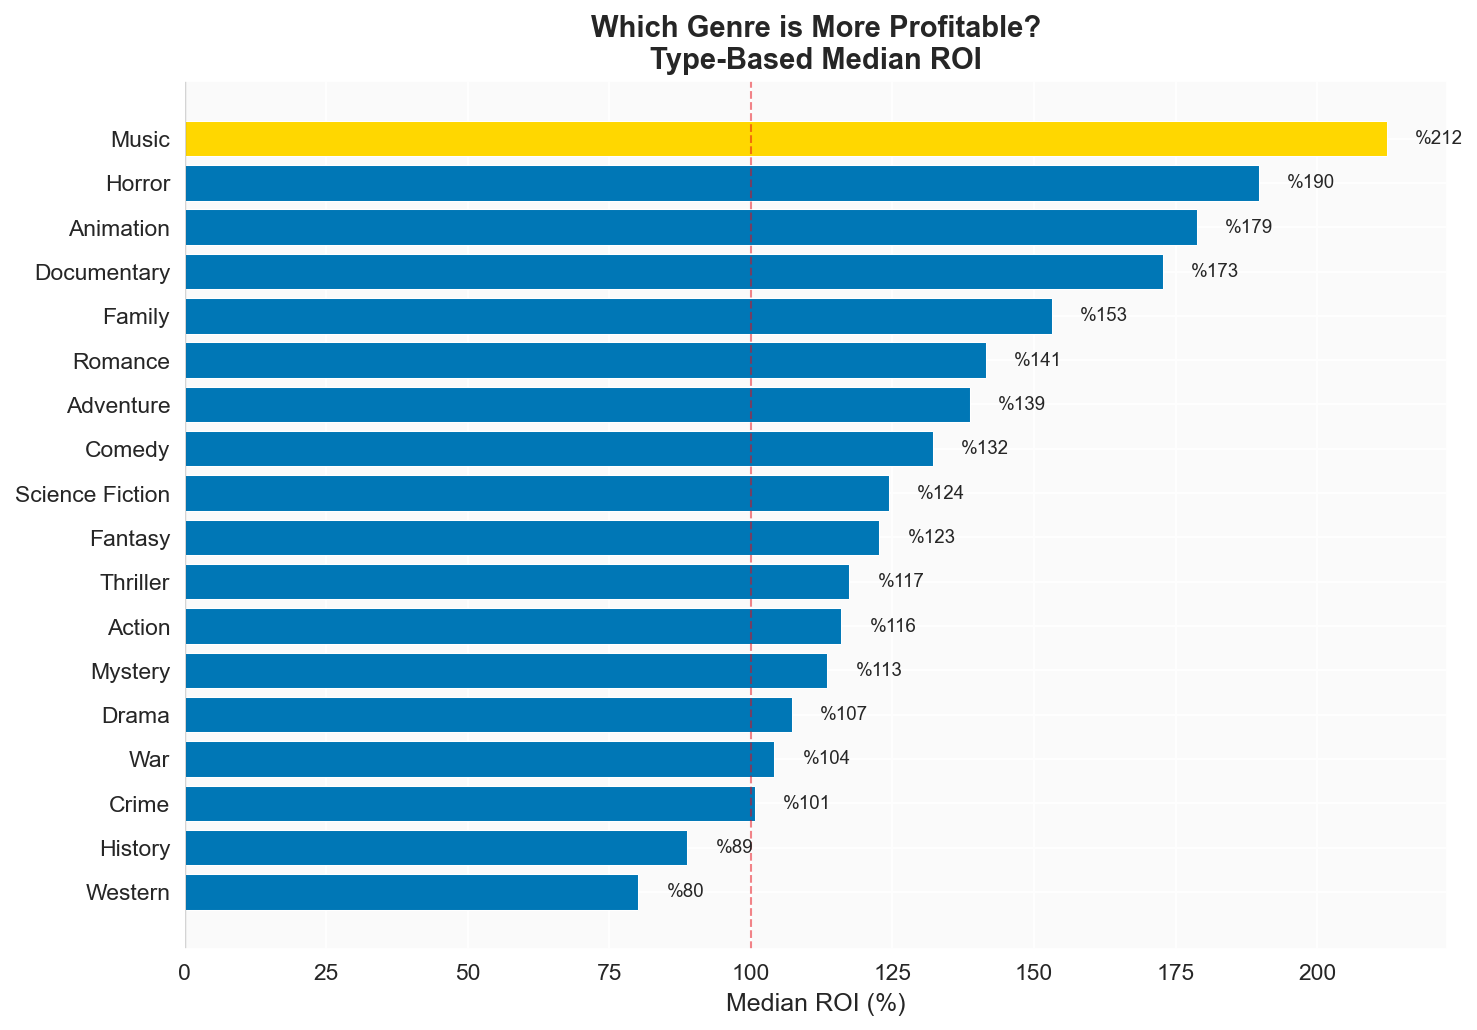

In [9]:
genre_data = []
for _, row in df_clean.iterrows():
    for genre in row['genre_list']:
        genre_data.append({'genre': genre, 'roi': row['roi'], 'revenue': row['revenue'],
                           'budget': row['budget'], 'vote_average': row['vote_average']})
genre_df = pd.DataFrame(genre_data)
genre_stats = genre_df.groupby('genre').agg(
    median_roi=('roi', 'median'),
    mean_revenue=('revenue', 'mean'),
    count=('roi', 'count'),
    mean_vote=('vote_average', 'mean')
).reset_index()
genre_stats = genre_stats[genre_stats['count'] >= 30].sort_values('median_roi', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = [COLORS['primary'] if x < 0 else COLORS['secondary'] if x > 200 else '#0077B6'
              for x in genre_stats['median_roi']]
bars = ax.barh(genre_stats['genre'], genre_stats['median_roi'], color=colors_bar, edgecolor='white', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=100, color=COLORS['primary'], linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Median ROI (%)', fontsize=12)
ax.set_title('Which Genre is More Profitable?\nType-Based Median ROI', fontsize=14, fontweight='bold')
for bar, val in zip(bars, genre_stats['median_roi']):
    ax.text(val + 5 if val >= 0 else val - 5, bar.get_y() + bar.get_height()/2,
            f'%{val:.0f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_facecolor('#fafafa')
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/02_genre_roi.png', bbox_inches='tight')

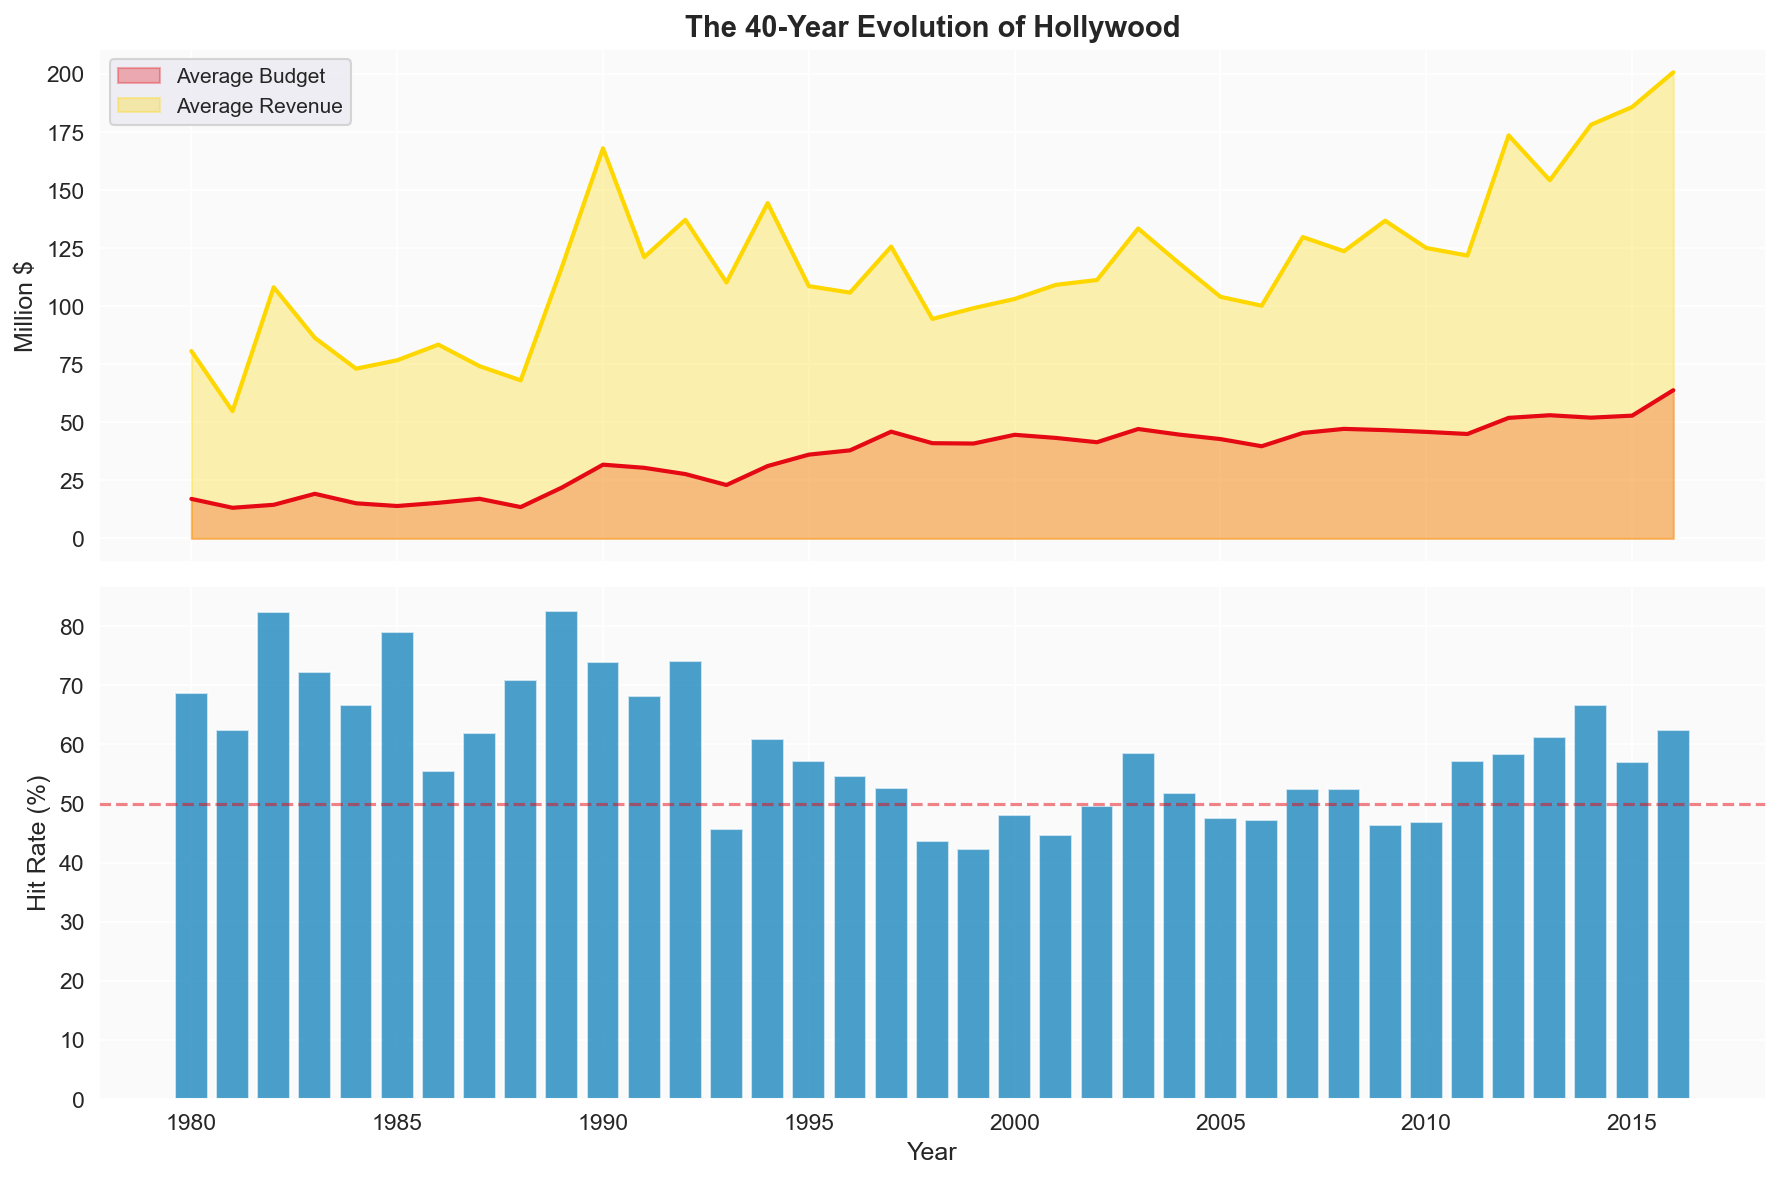

In [10]:
yearly = df_clean[df_clean['release_year'] >= 1980].groupby('release_year').agg(
    film_count=('title', 'count'),
    avg_budget=('budget', 'mean'),
    avg_revenue=('revenue', 'mean'),
    avg_roi=('roi', 'median'),
    hit_rate=('is_hit', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1 = axes[0]
ax1.fill_between(yearly['release_year'], yearly['avg_budget']/1e6, alpha=0.3, color=COLORS['primary'], label='Average Budget')
ax1.fill_between(yearly['release_year'], yearly['avg_revenue']/1e6, alpha=0.3, color=COLORS['secondary'], label='Average Revenue')
ax1.plot(yearly['release_year'], yearly['avg_budget']/1e6, color=COLORS['primary'], linewidth=2)
ax1.plot(yearly['release_year'], yearly['avg_revenue']/1e6, color=COLORS['secondary'], linewidth=2)
ax1.set_ylabel('Million $', fontsize=12)
ax1.set_title('The 40-Year Evolution of Hollywood', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_facecolor('#fafafa')

ax2 = axes[1]
ax2.bar(yearly['release_year'], yearly['hit_rate']*100, color=COLORS['gradient'][4], alpha=0.7)
ax2.axhline(y=50, color=COLORS['primary'], linestyle='--', alpha=0.5)
ax2.set_ylabel('Hit Rate (%)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_facecolor('#fafafa')

fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/03_yearly_trends.png', bbox_inches='tight')

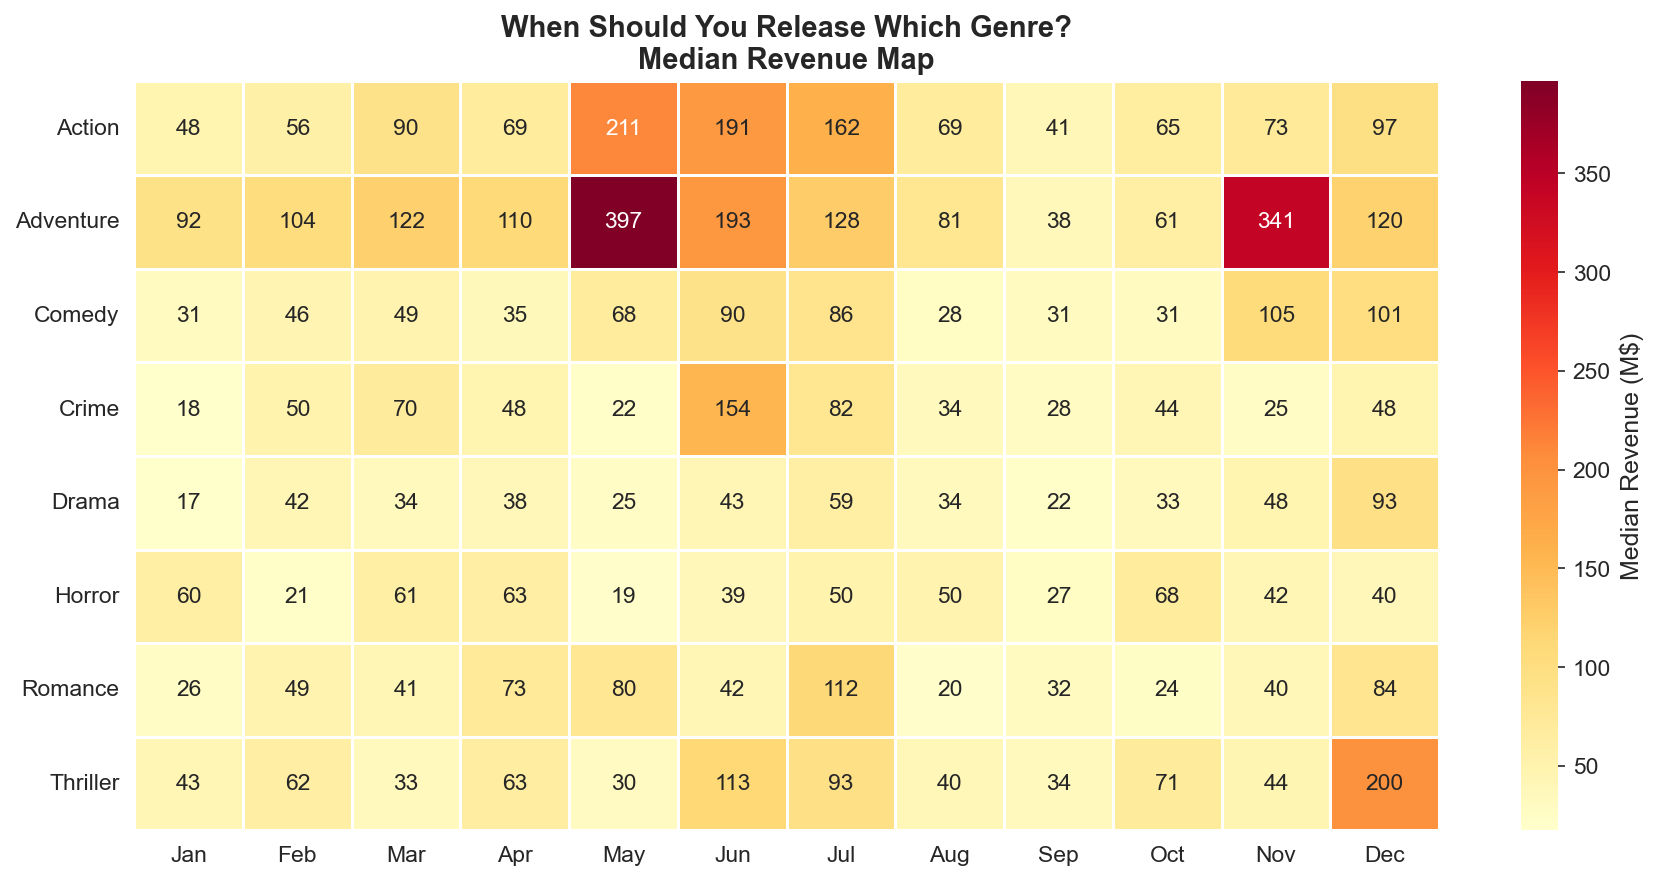

In [11]:
month_genre = []
for _, row in df_clean.iterrows():
    if pd.notna(row['release_month']):
        for g in row['genre_list'][:2]:
            month_genre.append({'month': int(row['release_month']), 'genre': g, 'revenue': row['revenue']})
mg_df = pd.DataFrame(month_genre)
top_genres = mg_df.groupby('genre')['revenue'].count().nlargest(8).index
mg_filtered = mg_df[mg_df['genre'].isin(top_genres)]
pivot = mg_filtered.pivot_table(values='revenue', index='genre', columns='month', aggfunc='median')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot / 1e6, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Median Revenue (M$)'})
ax.set_title('When Should You Release Which Genre?\nMedian Revenue Map', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/04_month_genre_heatmap.png', bbox_inches='tight')

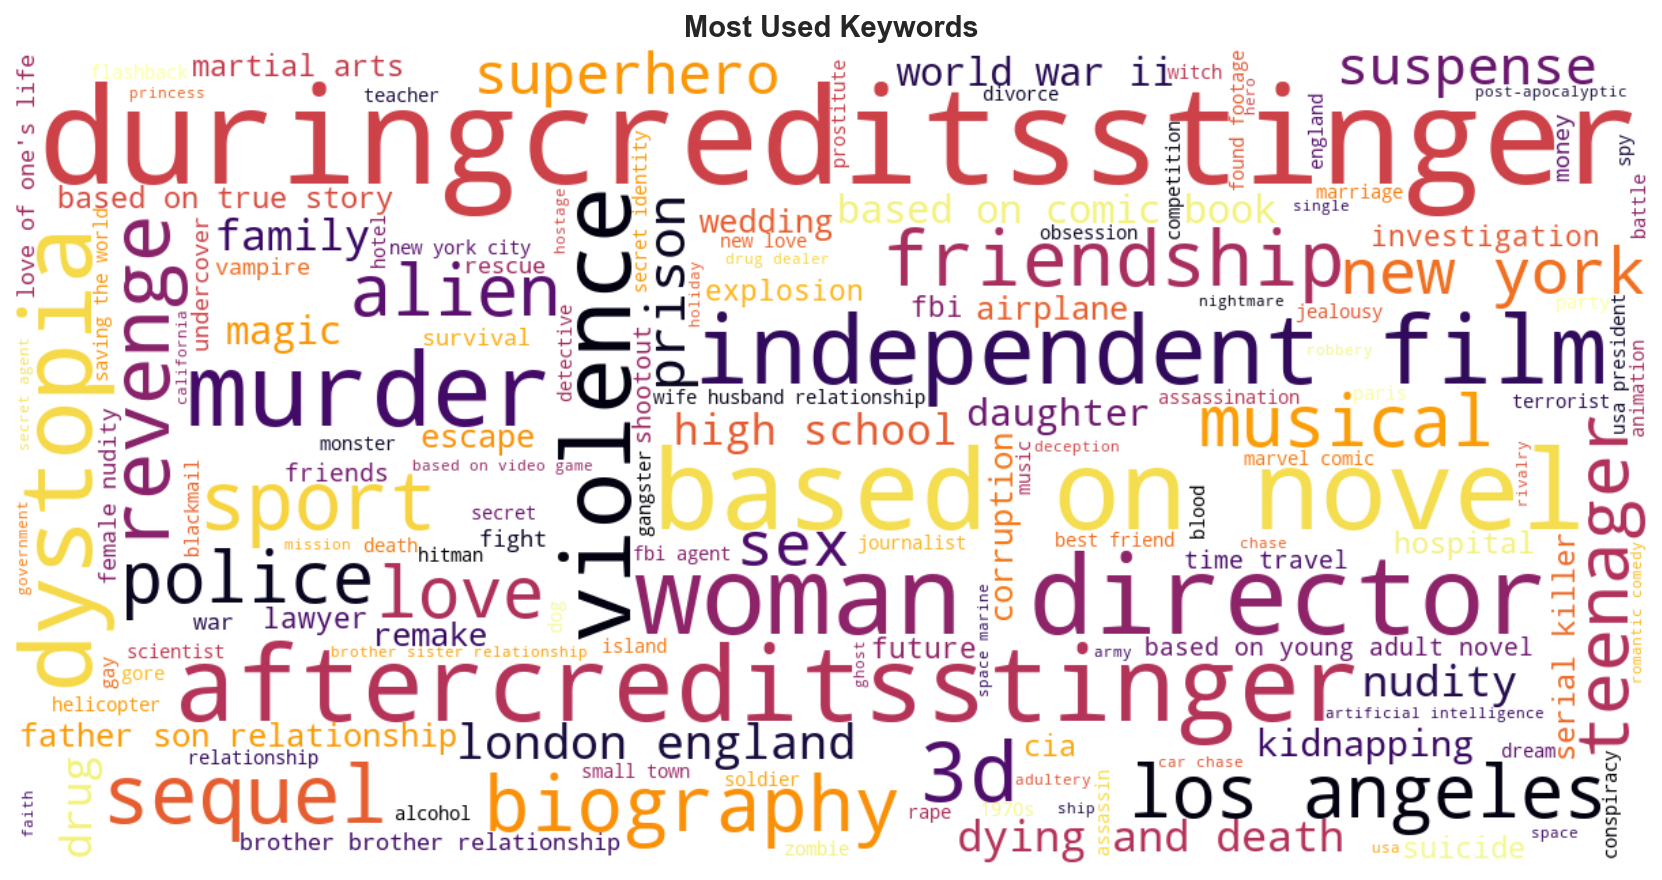

In [12]:
all_keywords = []
for kws in df_clean['keyword_list']:
    all_keywords.extend(kws)
kw_counts = Counter(all_keywords)

wc = WordCloud(width=1200, height=600, background_color='white',
               colormap='inferno', max_words=150, max_font_size=120,
               relative_scaling=0.5, prefer_horizontal=0.7)
wc.generate_from_frequencies(kw_counts)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Used Keywords', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/05_keyword_cloud.png', bbox_inches='tight')

In [13]:
#CHAPTER 3: FEATURE ENGINEERING

#most popular 10 genre
top_10_genres = genre_df['genre'].value_counts().head(10).index.tolist()
for g in top_10_genres:
    df_clean[f"genre_{g}"] = df_clean["genre_list"].apply(lambda x: 1 if g in x else 0)
    
#Keyword scores (most used keywords in hit films)
hit_keywords = []
for _, row in df_clean[df_clean['is_hit'] == 1].iterrows():
    hit_keywords.extend(row['keyword_list'])
hit_kw_counts = Counter(hit_keywords)
top_hit_kws = set([kw for kw, cnt in hit_kw_counts.most_common(50)])
df_clean['hit_keyword_score'] = df_clean['keyword_list'].apply(
    lambda kws: sum(1 for kw in kws if kw in top_hit_kws)
)

#Studio power (based on mean revenue)
studio_revenue = {}
for _, row in df_clean.iterrows():
    for comp in row['company_list']:
        if comp not in studio_revenue:
            studio_revenue[comp] = []
        studio_revenue[comp].append(row['revenue'])
studio_power = {k: np.mean(v) for k, v in studio_revenue.items() if len(v) >= 5}
df_clean['studio_power'] = df_clean['company_list'].apply(
    lambda comps: max([studio_power.get(c, 0) for c in comps]) if comps else 0
)

# Season
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}
df_clean['season'] = df_clean['release_month'].map(season_map)
season_dummies = pd.get_dummies(df_clean['season'], prefix='season', drop_first=True)
df_clean = pd.concat([df_clean, season_dummies], axis=1)

# Keyword count, genre count
df_clean['n_genres'] = df_clean['genre_list'].apply(len)
df_clean['n_keywords'] = df_clean['keyword_list'].apply(len)
df_clean['n_companies'] = df_clean['company_list'].apply(len)
df_clean['budget_per_minute'] = df_clean['budget'] / df_clean['runtime'].clip(lower=1)

#Overview length
df_clean['overview_length'] = df_clean['overview'].fillna('').apply(len)

feature_cols = (
    ['log_budget', 'popularity', 'runtime', 'vote_average', 'vote_count',
     'hit_keyword_score', 'studio_power', 'n_genres', 'n_keywords',
     'n_companies', 'budget_per_minute', 'overview_length', 'release_month'] +
    [f'genre_{g}' for g in top_10_genres] +
    [c for c in df_clean.columns if c.startswith('season_')]
)

print(f"Total number of features: {len(feature_cols)}")
print(f"Features: {feature_cols[:8]}...")

Total number of features: 26
Features: ['log_budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'hit_keyword_score', 'studio_power', 'n_genres']...


In [14]:
#CHAPTER 4: Machine Learning Models


X = df_clean[feature_cols].fillna(0)
y = df_clean["log_revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Model 1: Linear Regressiom
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

#Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_split=10, 
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

#Model 3: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                               min_samples_split=10, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

#Comparing Results
results = {}
for name, pred, model in [("Linear Regression", lr_pred, lr),
                          ("Random Forest", rf_pred, rf),
                          ("Gradient Boosting", gb_pred, gb)]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"\n{name}:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")


Linear Regression:
MAE: 0.8406
RMSE: 1.1959
R2: 0.5757

Random Forest:
MAE: 0.7214
RMSE: 1.0479
R2: 0.6742

Gradient Boosting:
MAE: 0.7160
RMSE: 1.0413
R2: 0.6783


In [15]:
#Cross validation for the best model
cv_scores = cross_val_score(gb, X, y, cv=5, scoring = "r2")
print(f"Gradient Boosting CV R2 : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Gradient Boosting CV R2 : 0.3302 (+/- 0.1872)


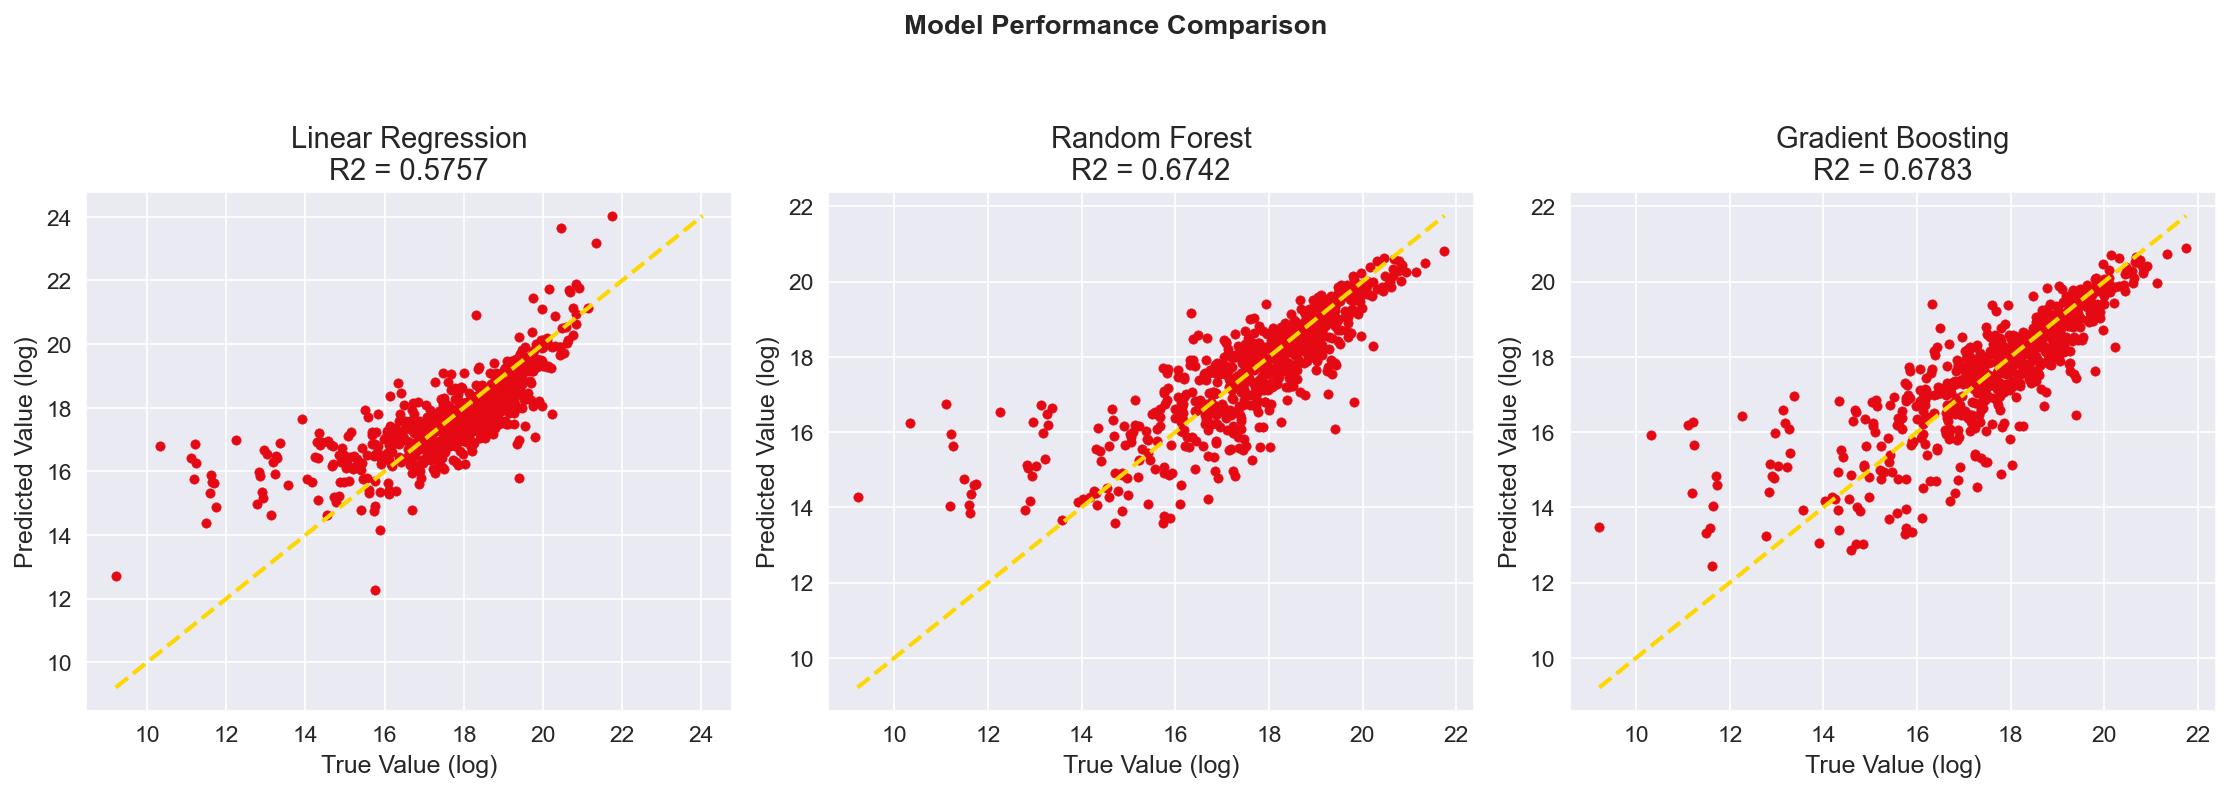

In [16]:
#Model Comparison Graph
fig, ax = plt.subplots(1,3,figsize=(15,5))
for ax, (name, pred) in zip(ax, [("Linear Regression", lr_pred),
                                 ("Random Forest", rf_pred),
                                 ("Gradient Boosting", gb_pred)]):
    ax.scatter(y_test, pred, s=20, c=COLORS["primary"], linewidth=0.3)
    mn, mx = min(y_test.min(), pred.min()), max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], color=COLORS["secondary"], linewidth=2, linestyle="--")
    ax.set_xlabel("True Value (log)")
    ax.set_ylabel("Predicted Value (log)")
    ax.set_title(f"{name}\nR2 = {results[name]['R2']:.4f}")
fig.suptitle("Model Performance Comparison", y = 1.05, fontweight="bold")
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/06_model_comparison.png', bbox_inches='tight')

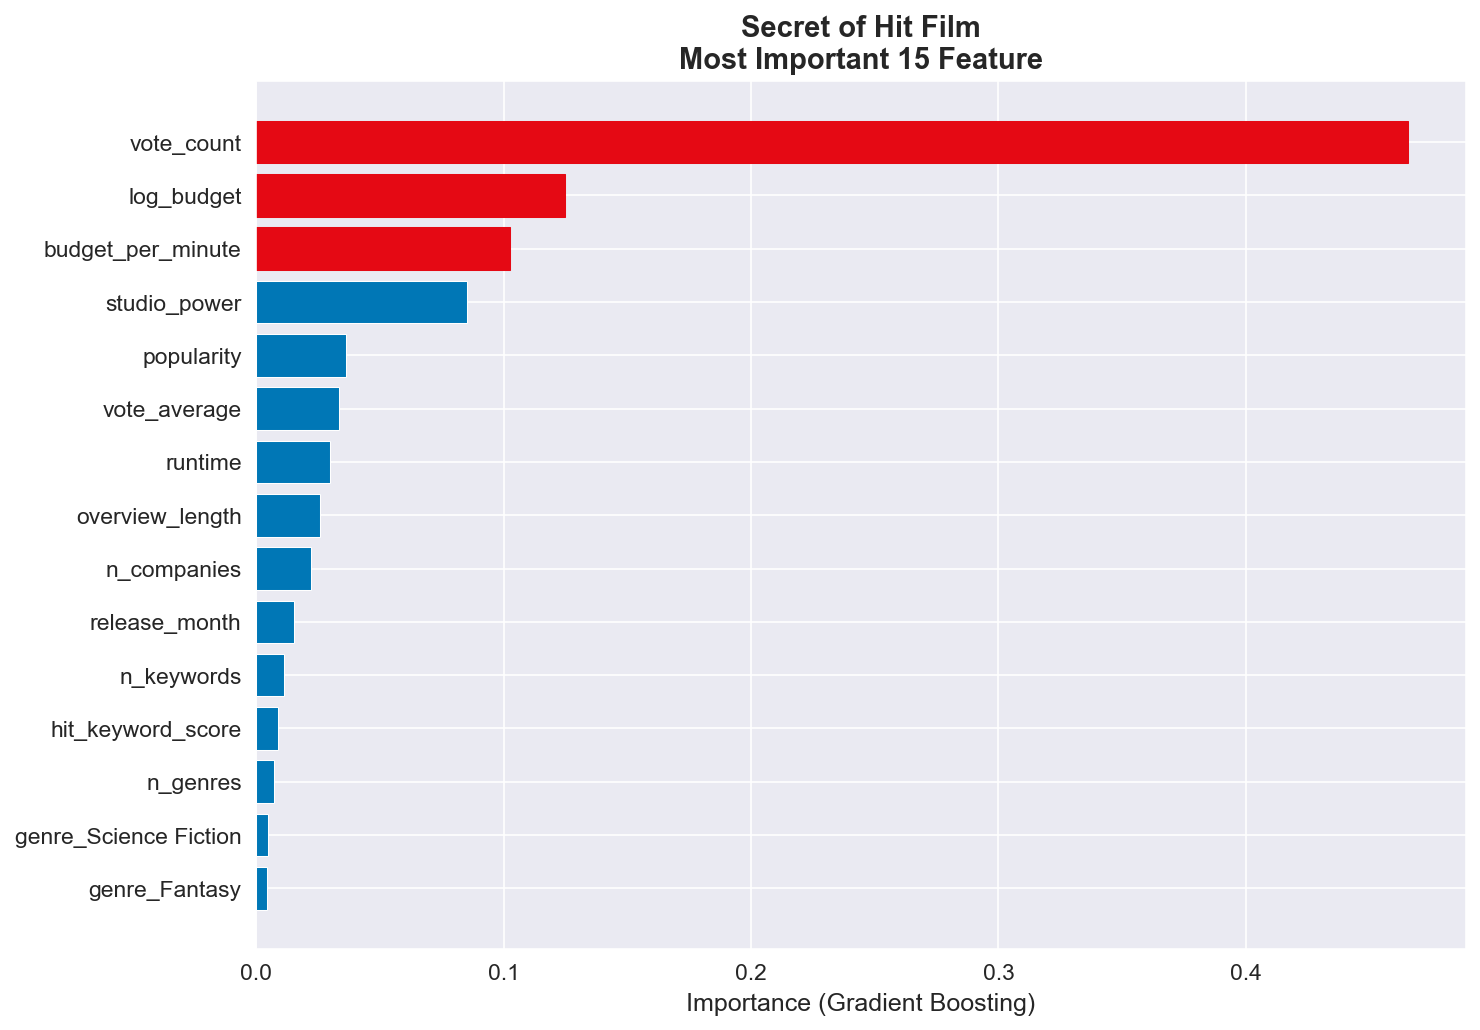

In [17]:
#Feature Importance Graph
importances = pd.DataFrame({
    "feature" : feature_cols,
    "importance" : gb.feature_importances_
}).sort_values("importance", ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importances['feature'], importances['importance'],
               color=COLORS['gradient'][4], edgecolor='white', linewidth=0.5)
#Top 3
for bar in bars[-3:]:
    bar.set_color(COLORS['primary'])
ax.set_xlabel('Importance (Gradient Boosting)', fontsize=12)
ax.set_title('Secret of Hit Film\nMost Important 15 Feature', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/07_feature_importance.png', bbox_inches='tight')

In [18]:
#CHAPTER 5: FILM GENERATIVE ENGINE (Film Recipe)

#Find the best combination based on ROI
#Top genre pairs
genre_pairs = []
for _, row in df_clean.iterrows():
    genres = sorted(row['genre_list'])
    for i in range(len(genres)):
        for j in range(i+1, len(genres)):
            genre_pairs.append({
                "pair" : f"{genres[i]}-{genres[j]}",
                "roi" : row["roi"],
                "revenue" : row["revenue"],
            })
gp_df = pd.DataFrame(genre_pairs)
gp_stats = gp_df.groupby('pair').agg(
    median_roi=('roi', 'median'),
    count=('roi', 'count'),
    avg_revenue=('revenue', 'mean')
).reset_index()
gp_stats = gp_stats[gp_stats['count'] >= 10].sort_values('median_roi', ascending=False)
print("THE MOST PROFITABLE GENRE COMBINATIONS:")
print(gp_stats.head(10).to_string(index=False))

#Find the best combination based on month-genre
best_month = df_clean.groupby("release_month").agg(
    median_roi=('roi', 'median'),
    count=("title", "count"),
).reset_index().sort_values('median_roi', ascending=False)
print("\nTHE MOST PROFITABLE RELEASE MONTHS:")
month_names = {1:"January", 2:"February", 3:"March", 4:"April", 5:"May", 6:"June",
               7:"July", 8:"August", 9:"September", 10:"October", 11:"November", 12:"December"}
for _, row in best_month.head(5).iterrows():
    print(f"  {month_names[int(row['release_month'])]}: Medyan ROI %{row['median_roi']:.0f} ({int(row['count'])} film)")
    
#Budget Sweet Spot
budget_bins = pd.cut(df_clean['budget'], bins=[0, 5e6, 15e6, 40e6, 100e6, 400e6],
                     labels=["< 5M", "5-15M", "15-40M", "40-100M", "100M+"])
budget_perf = df_clean.groupby(budget_bins, observed = True).agg(
    median_roi=("roi", "median"),
    hit_rate=("is_hit", "mean"),
    count=("title", "count"),
).reset_index()
print("\nBUDGET SWEET SPOT ANALYSIS:")
print(budget_perf.to_string(index=False))

THE MOST PROFITABLE GENRE COMBINATIONS:
               pair  median_roi  count  avg_revenue
       Family-Music  270.552426     24 1.281874e+08
       Comedy-Music  265.559066     46 8.691507e+07
      Music-Romance  265.559066     46 8.362581e+07
  Animation-Fantasy  212.750000     49 2.888320e+08
    Animation-Drama  212.304554     13 2.475469e+08
        Drama-Music  212.066695     64 7.831190e+07
   Animation-Comedy  202.715716    101 3.201141e+08
    Animation-Music  192.987652     11 1.815806e+08
   Animation-Family  185.589630    163 3.060838e+08
Adventure-Animation  179.774439     94 2.950620e+08

THE MOST PROFITABLE RELEASE MONTHS:
  June: Medyan ROI %194 (291 film)
  May: Medyan ROI %170 (244 film)
  December: Medyan ROI %167 (333 film)
  July: Medyan ROI %165 (263 film)
  November: Medyan ROI %161 (255 film)

BUDGET SWEET SPOT ANALYSIS:
 budget  median_roi  hit_rate  count
   < 5M  394.147733  0.701863    483
  5-15M  153.333333  0.579872    626
 15-40M   96.785023  0.491772

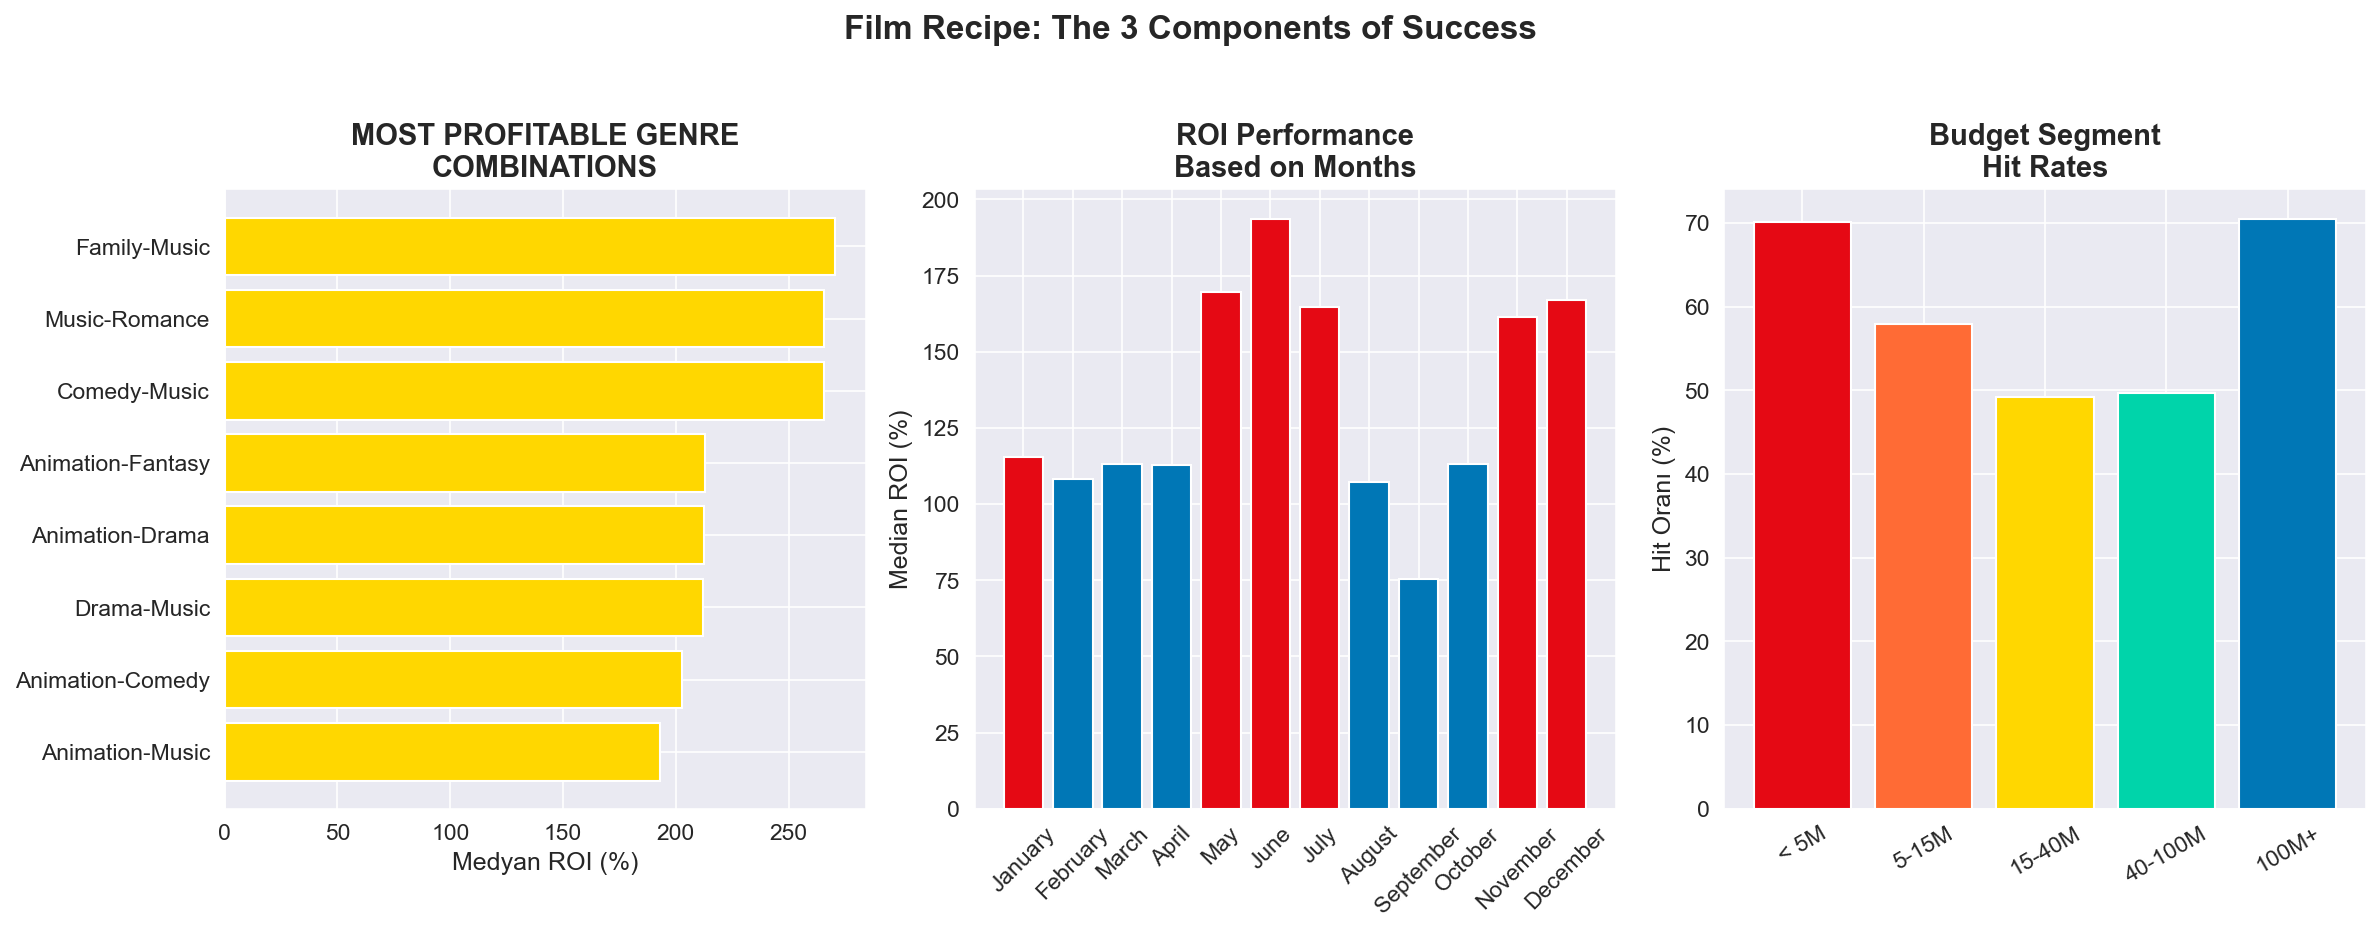

In [19]:
#Film Recipe Graphs
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

#Top genre pairs
top_pairs = gp_stats.head(8).sort_values('median_roi')
axes[0].barh(top_pairs['pair'], top_pairs['median_roi'], color=COLORS['secondary'],
             edgecolor='white')
axes[0].set_xlabel('Medyan ROI (%)')
axes[0].set_title('MOST PROFITABLE GENRE\nCOMBINATIONS', fontweight='bold')

#Best months
month_roi = best_month.sort_values('release_month')
month_labels = [month_names[int(m)] for m in month_roi['release_month']]
bar_colors = ['#E50914' if r > month_roi['median_roi'].median() else '#0077B6'
              for r in month_roi['median_roi']]
axes[1].bar(month_labels, month_roi['median_roi'], color=bar_colors)
axes[1].set_ylabel('Median ROI (%)')
axes[1].set_title('ROI Performance\nBased on Months', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

#Budget Distribution
axes[2].bar(budget_perf['budget'].astype(str), budget_perf['hit_rate']*100,
            color=COLORS['gradient'], edgecolor='white')
axes[2].set_ylabel('Hit Oranı (%)')
axes[2].set_title('Budget Segment\nHit Rates', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

fig.suptitle('Film Recipe: The 3 Components of Success', fontsize=16, fontweight='bold', y=1.03)
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/08_movie_recipe.png', bbox_inches='tight')

In [20]:
#CHAPTER 6: CONCLUSION and SUMMARY

best_model = 'Gradient Boosting'
best_r2 = results[best_model]['R2']

print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    PROJECT RESULTS                           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📊 Number of Films Analyzed:  {df_clean.shape[0]:>6}         ║
║  🏆 The Best Model:               {best_model:<25}   ║
║  📈 R² Score:                    {best_r2:.4f}                     ║
║  📈 CV R² Score:                 {cv_scores.mean():.4f} (±{cv_scores.std()*2:.4f})          ║
║                                                              ║
║  🎯 TOP 3 BOX OFFICE SUCCESS FACTORS:                       ║
║  1. {importances.iloc[-1]['feature']:<50} ║
║  2. {importances.iloc[-2]['feature']:<50} ║
║  3. {importances.iloc[-3]['feature']:<50} ║
║                                                              ║
║  💡 The Most Profitable Genres Combination:                              ║
║     {gp_stats.iloc[0]['pair']:<40} ROI: %{gp_stats.iloc[0]['median_roi']:.0f}  ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║                    PROJECT RESULTS                           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📊 Number of Films Analyzed:    3211         ║
║  🏆 The Best Model:               Gradient Boosting           ║
║  📈 R² Score:                    0.6783                     ║
║  📈 CV R² Score:                 0.3302 (±0.1872)          ║
║                                                              ║
║  🎯 TOP 3 BOX OFFICE SUCCESS FACTORS:                       ║
║  1. vote_count                                         ║
║  2. log_budget                                         ║
║  3. budget_per_minute                                  ║
║                                                              ║
║  💡 The Most Profitable Genres Combination:                              ║
║     Family-Music                             ROI: %2